In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("./data/titanic_clean.csv")

In [5]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
681,1,1,male,27.0,0,0,76.7292,C
43,1,2,female,3.0,1,2,41.5792,C
556,1,1,female,48.0,1,0,39.6000,C
553,1,3,male,22.0,0,0,7.2250,C


In [6]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

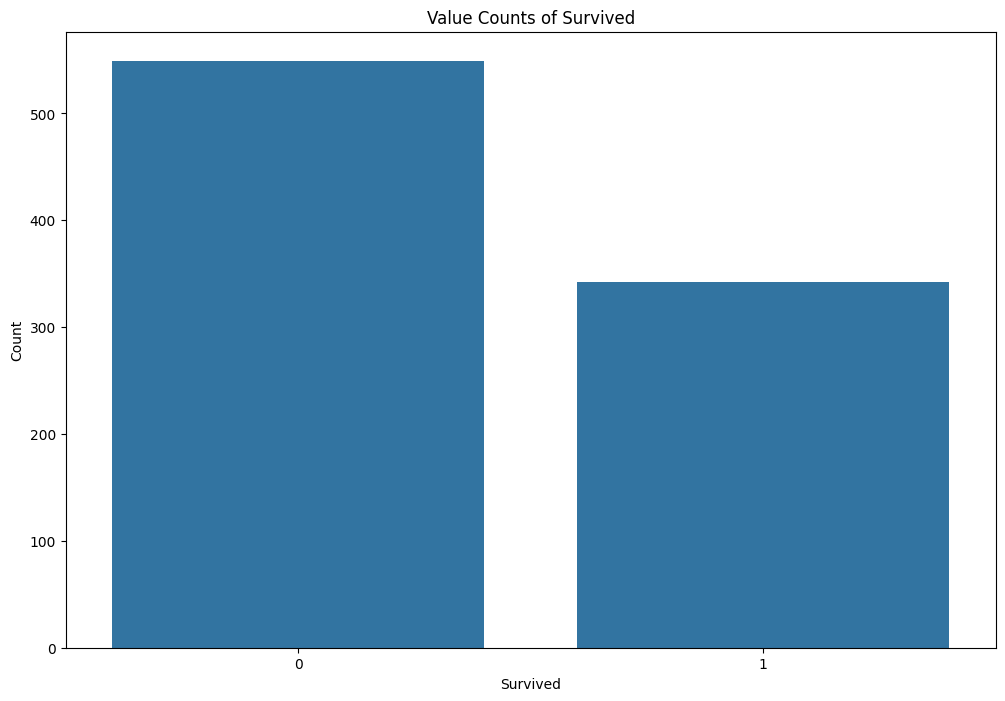

In [7]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

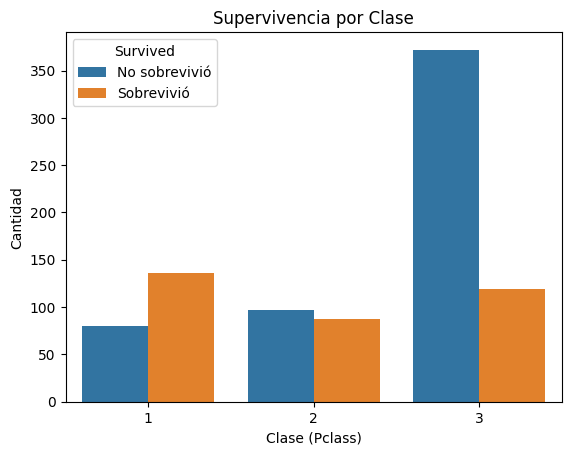

In [8]:
sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived'
)

plt.title('Supervivencia por Clase')
plt.xlabel('Clase (Pclass)')
plt.ylabel('Cantidad')
plt.legend(title='Survived', labels=['No sobrevivió', 'Sobrevivió'])

plt.show()

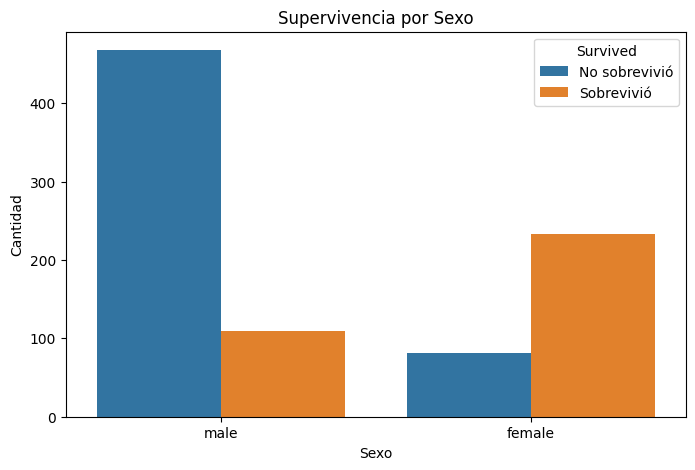

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Sex',
    hue='Survived'
)

plt.title('Supervivencia por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad')
plt.legend(title='Survived', labels=['No sobrevivió', 'Sobrevivió'])

plt.show()

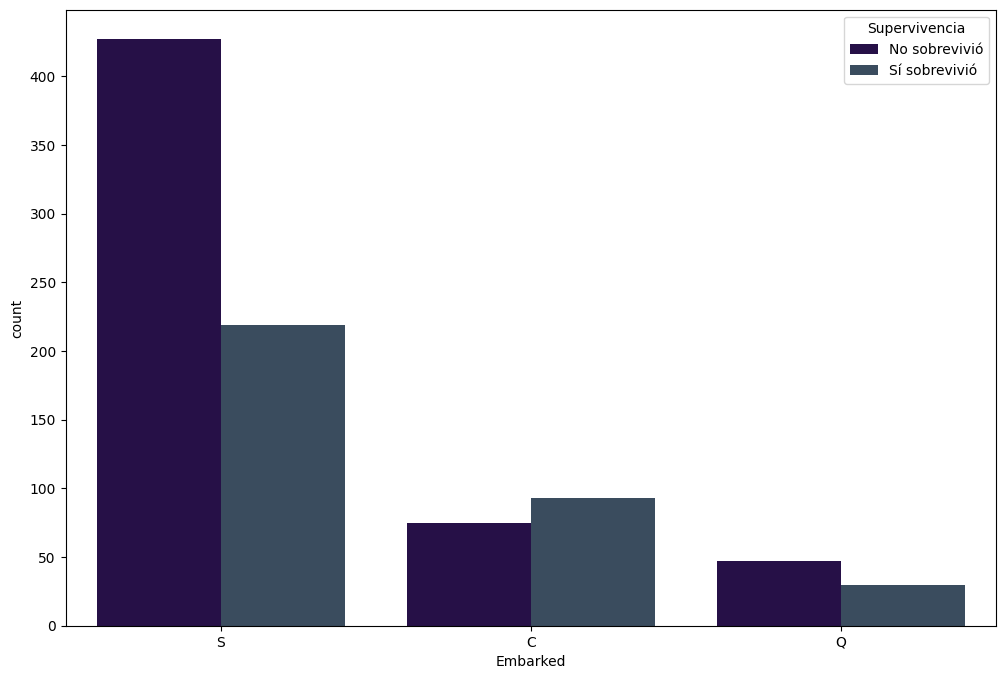

In [10]:
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

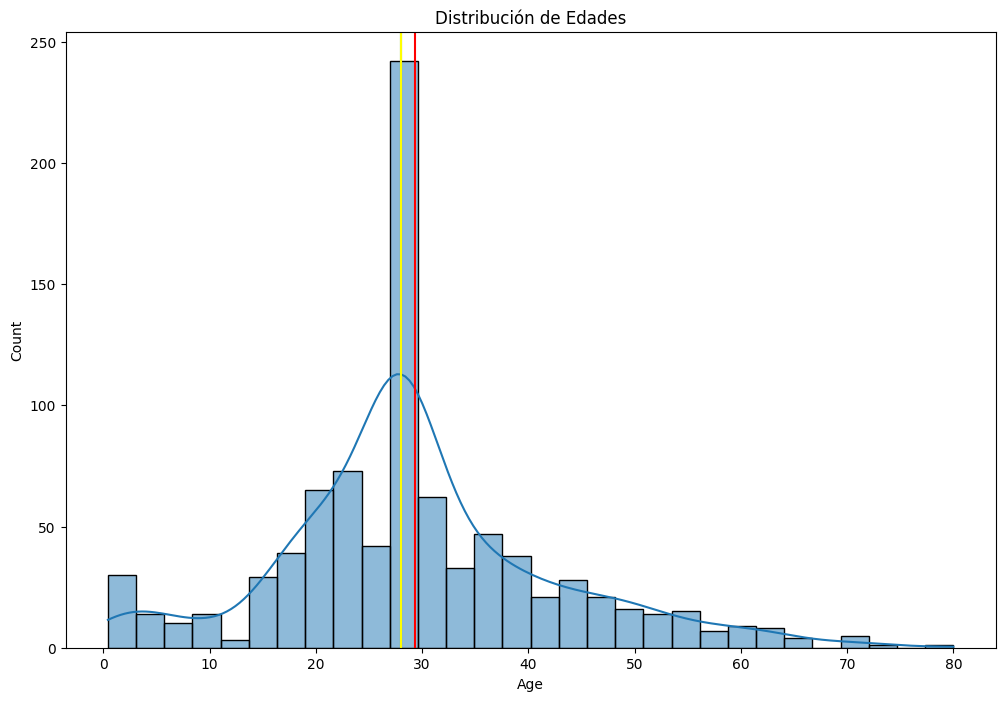

Media: 29.36158249158249
Mediana: 28.0
Moda: 28.0


In [11]:
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'yellow')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

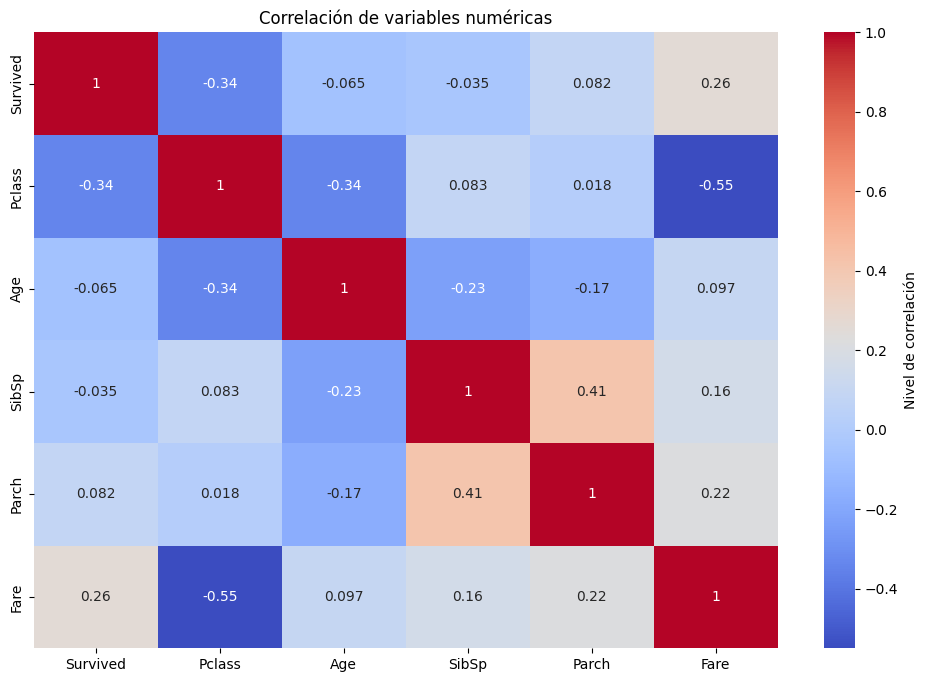

In [12]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

Agrupa las edades en categorías (Infante, Niño, Adolescente, Joven Adulto, Adulto, Mayor) y crea una gráfica que muestre la tasa de supervivencia por grupo de edad.

Text(0, 0.5, 'Tasa de Supervivencia')

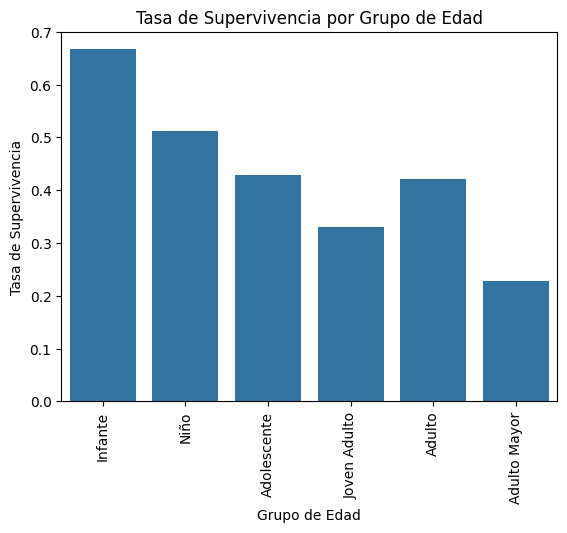

In [13]:
edad_rangos = [0,3,12,18,30,60,100]
categorias = ['Infante','Niño', 'Adolescente', 'Joven Adulto', 'Adulto', 'Adulto Mayor']

df['AgeGroup'] = pd.cut(df['Age'], bins = edad_rangos, labels= categorias)

tasa_supervivencia = df.groupby('AgeGroup')['Survived'].mean().reset_index()

sns.barplot(data = tasa_supervivencia, x = 'AgeGroup', y = 'Survived')
plt.xticks(rotation=90)
plt.title('Tasa de Supervivencia por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Tasa de Supervivencia')

Crea una gráfica que muestre el conteo de pasajeros en cada clase (Pclass).

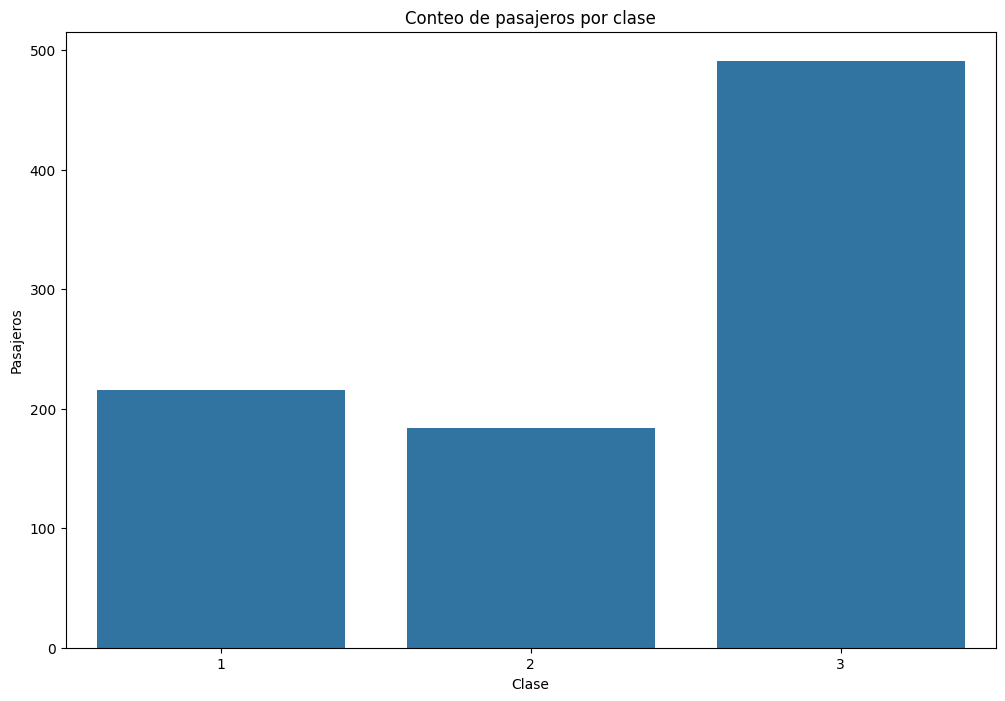

In [14]:
conteo= df['Pclass'].value_counts()

plt.figure(figsize=(12, 8))

sns.barplot(conteo)
plt.title('Conteo de pasajeros por clase')
plt.xlabel('Clase')
plt.ylabel('Pasajeros')
plt.show()


Crea una gráfica que muestre la distribución de género dentro de cada clase de pasajero (Pclass).

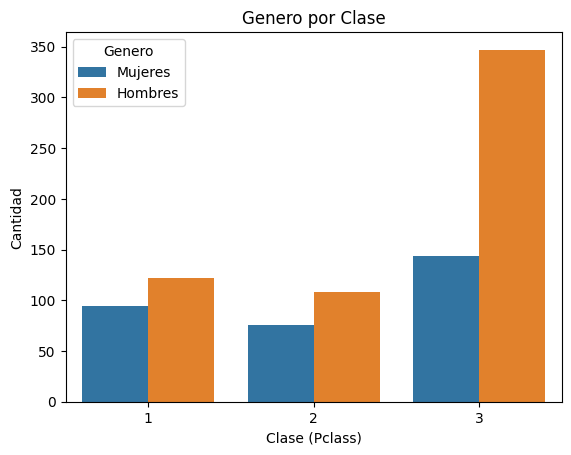

In [15]:
sns.countplot(
    data=df,
    x='Pclass',
    hue='Sex'
)

plt.title('Genero por Clase')
plt.xlabel('Clase (Pclass)')
plt.ylabel('Cantidad')
plt.legend(title='Genero', labels=['Mujeres', 'Hombres'])

plt.show()

Crea una gráfica que muestre la distribución de clase de pasajero por puerto de embarque (Embarked).

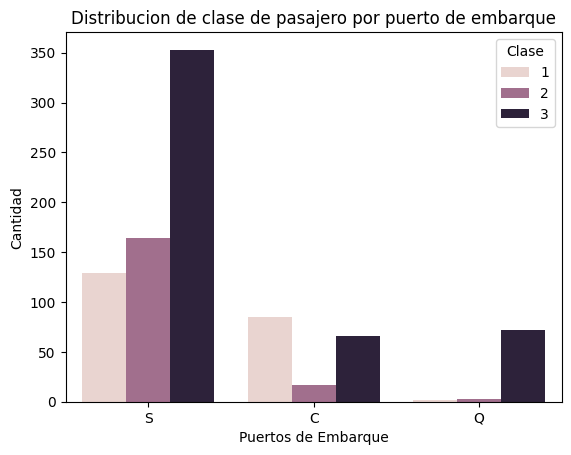

In [16]:
sns.countplot(
    data=df,
    x='Embarked',
    hue='Pclass'
)

plt.title('Distribucion de clase de pasajero por puerto de embarque')
plt.xlabel('Puertos de Embarque')
plt.ylabel('Cantidad')
plt.legend(title='Clase', labels=['1', '2', '3'])

plt.show()

Crea una gráfica que muestre el conteo de pasajeros por género (Sex).

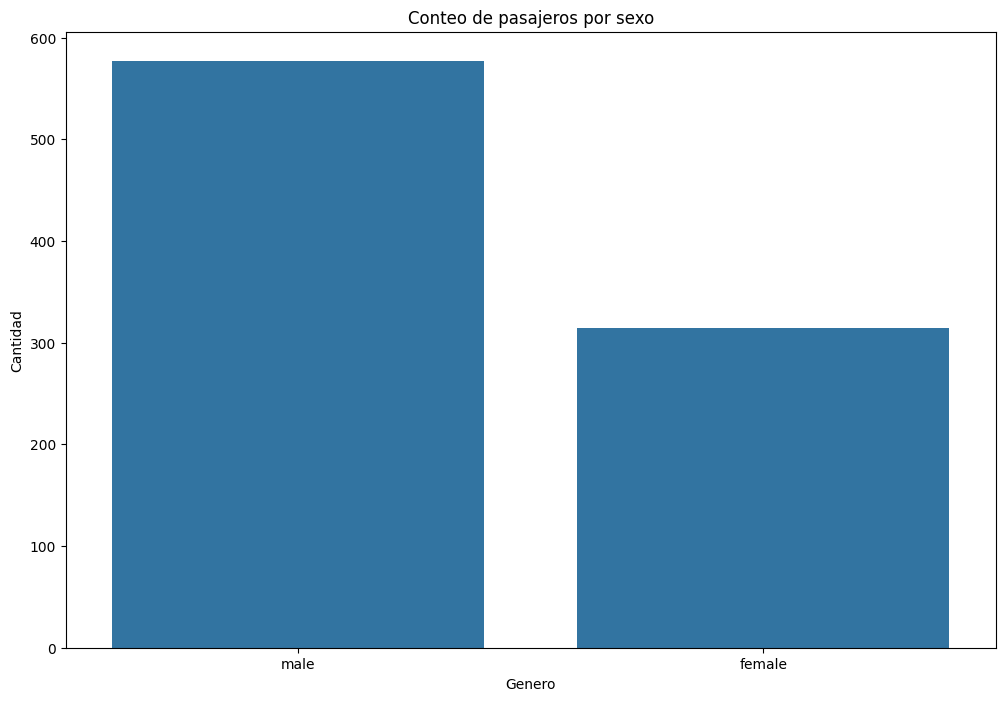

In [17]:
distribucion = df['Sex'].value_counts()

plt.figure(figsize=(12,8))

sns.barplot(distribucion)

plt.title("Conteo de pasajeros por sexo")
plt.xlabel("Genero")
plt.ylabel('Cantidad')

plt.show()

Encuentra y muestra los valores máximo y mínimo de la columna de edad.

In [18]:
edad_max = df['Age'].max()
edad_min = df["Age"].min()
print(f'Los valores maximos de la columna edad son: {edad_max} y los valores minimos son {edad_min}')


Los valores maximos de la columna edad son: 80.0 y los valores minimos son 0.42


Crea un diagrama de caja (boxplot) que muestre los outliers en la columna de tarifa (Fare).

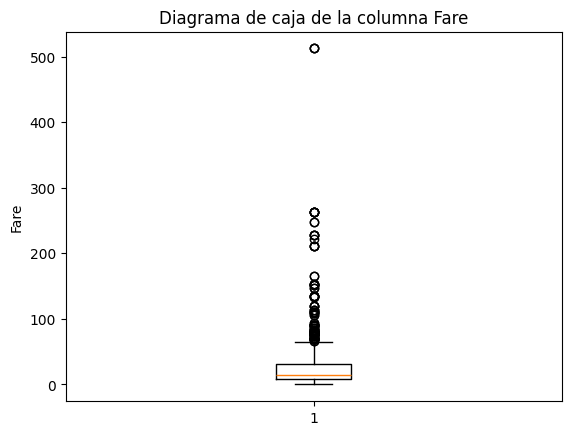

In [19]:
datos = df['Fare']
plt.boxplot(datos)
plt.title('Diagrama de caja de la columna Fare')
plt.ylabel('Fare') 
plt.show()

Filtra y muestra los datos de los pasajeros que pagaron 0 en tarifa.

In [20]:
filtrado = df[df['Fare'].isin([0])]
print (filtrado)

     Survived  Pclass   Sex   Age  SibSp  Parch  Fare Embarked      AgeGroup
179         0       3  male  36.0      0      0   0.0        S        Adulto
263         0       1  male  40.0      0      0   0.0        S        Adulto
271         1       3  male  25.0      0      0   0.0        S  Joven Adulto
277         0       2  male  28.0      0      0   0.0        S  Joven Adulto
302         0       3  male  19.0      0      0   0.0        S  Joven Adulto
413         0       2  male  28.0      0      0   0.0        S  Joven Adulto
466         0       2  male  28.0      0      0   0.0        S  Joven Adulto
481         0       2  male  28.0      0      0   0.0        S  Joven Adulto
597         0       3  male  49.0      0      0   0.0        S        Adulto
633         0       1  male  28.0      0      0   0.0        S  Joven Adulto
674         0       2  male  28.0      0      0   0.0        S  Joven Adulto
732         0       2  male  28.0      0      0   0.0        S  Joven Adulto

Crea una gráfica que muestre el conteo de pasajeros por número de hermanos/esposos a bordo (SibSp).

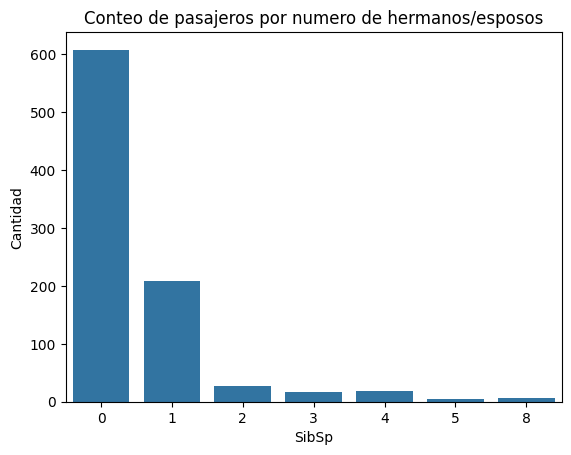

In [26]:
sns.countplot(
    data = df,
    x = "SibSp")
plt.title("Conteo de pasajeros por numero de hermanos/esposos")
plt.xlabel("SibSp")
plt.ylabel("Cantidad")
plt.show()

Crea una gráfica que muestre la tasa de supervivencia basada en el número de hermanos/esposos a bordo (SibSp).

Text(0, 0.5, 'Tasa de Supervivencia (%)')

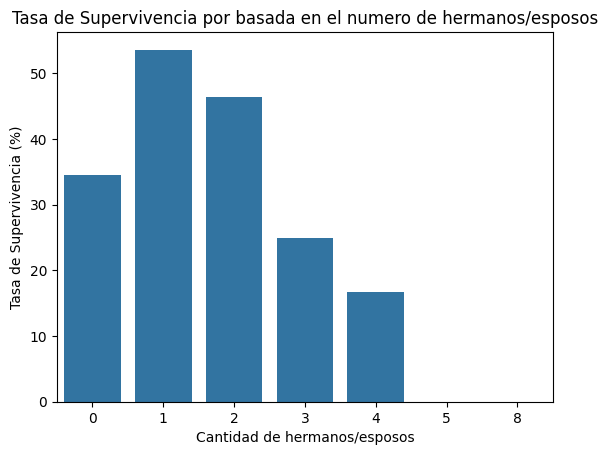

In [53]:
tasa_supervivencia = df.groupby('SibSp')['Survived'].mean().reset_index()
porcentaje = tasa_supervivencia['Survived']*100
sns.barplot(data = tasa_supervivencia, x = 'SibSp', y = porcentaje)
plt.title('Tasa de Supervivencia por basada en el numero de hermanos/esposos')
plt.xlabel('Cantidad de hermanos/esposos')
plt.ylabel('Tasa de Supervivencia (%)')

Calcula y muestra el porcentaje de supervivencia para cada valor de SibSp.

In [54]:
tasa_supervivencia = df.groupby('SibSp')['Survived'].mean().reset_index()
porcentaje = tasa_supervivencia['Survived']*100
print (f"El porcentaje de supervivencia por cada valor de SibSp es: ")
print(porcentaje)

El porcentaje de supervivencia por cada valor de SibSp es: 
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
6     0.000000
Name: Survived, dtype: float64
